In [2]:
import pygimli as pg 
import matplotlib.pyplot as plt
import numpy as np
from pygimli.physics import ert
import pygimli.meshtools as mt
from scipy.interpolate import griddata
import pandas as pd
import os
output_dir="timelapse1_v2"
os.makedirs(output_dir, exist_ok=True)

30/03/26 - 18:50:08 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 
30/03/26 - 18:50:09 - pyGIMLi - INFO - Cache c:\Users\sider\.conda\envs\pg\Lib\site-packages\pygimli\physics\ert\ert.py:createGeometricFactors restored (0.0s x 118): C:\Users\sider\AppData\Roaming\pygimli\Cache\17970140561219481632


Data: Sensors: 21 data: 171, nonzero entries: ['a', 'b', 'k', 'm', 'n', 'valid']


30/03/26 - 18:50:09 - pyGIMLi - INFO - Data error estimate (min:max)  0.05000646492989695 : 0.05498040002706264
30/03/26 - 18:50:10 - pyGIMLi - INFO - 0.662636985614011 1229.5566691596337
30/03/26 - 18:50:10 - pyGIMLi - INFO - Simulated data:  Data: Sensors: 21 data: 171, nonzero entries: ['a', 'b', 'err', 'i', 'k', 'm', 'n', 'r', 'rhoa', 'u', 'valid']
30/03/26 - 18:50:10 - pyGIMLi - INFO - The data contains :  ['a', 'b', 'err', 'i', 'ip', 'iperr', 'k', 'm', 'n', 'r', 'rhoa', 'u', 'valid']
30/03/26 - 18:50:10 - pyGIMLi - INFO - Sim rhoa (min/max) :  57.690391453248104 140.35602680087445
30/03/26 - 18:50:10 - pyGIMLi - INFO - Selected data noise % (min/ma)x :  5.000646492989695 5.498040002706264
30/03/26 - 18:50:10 - pyGIMLi - INFO - filtered rhoa minmax dd :  57.690391453248104 140.35602680087445


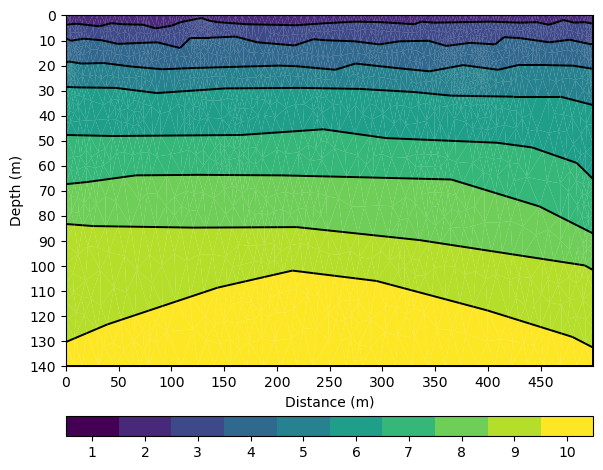

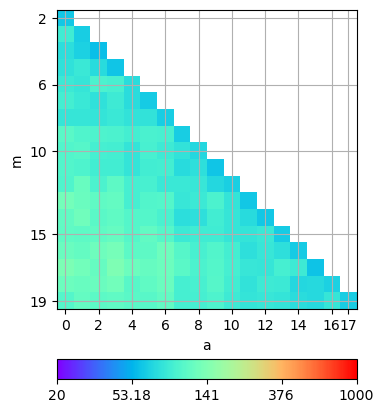

In [4]:
world=mt.createWorld(start=[-1000,0],end=[1500,-1000],worldMarker=1)
poly=mt.createRectangle(start=[0, -140], end=[500, 0], marker=1)

interfaces = []

for i in range(9):
    coords = np.loadtxt(f'shape_{i}.txt')
    line = mt.createPolygon(coords, isClosed=False)
    interfaces.append(line)

geom = mt.mergePLC([world] + interfaces + [poly])

geom.addRegionMarker(pos=[0, -1], marker=2)
geom.addRegionMarker(pos=[0, -6], marker=3)
geom.addRegionMarker(pos=[0, -12], marker=4)
geom.addRegionMarker(pos=[0, -23], marker=5)
geom.addRegionMarker(pos=[0, -40], marker=6)
geom.addRegionMarker(pos=[0, -60], marker=7)
geom.addRegionMarker(pos=[0, -80], marker=8)
geom.addRegionMarker(pos=[0, -100], marker=9)
geom.addRegionMarker(pos=[0, -140], marker=10)


mesh_cut = mt.createMesh(geom, quality=34)

x_min,x_max= 0,500
y_min,y_max= -140,0

ax, cbar = pg.show(mesh_cut, data=mesh_cut.cellMarkers(), 
                   showMesh=False, aspect='auto', 
                   cmap=plt.get_cmap("viridis", 10))
cbar.mappable.set_clim(0.5, 10.5)
cbar.set_ticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

ax.set_xlim(0, 500)
ax.set_ylim(-140, 0)
ax.set_yticks(np.arange(-140, 1, 10)) 
ax.set_xticks(np.arange(0, 500, 50)) 
ax.set_xlabel("Distance (m)")   
ax.set_ylabel("Depth (m)")
ax.figure.savefig(os.path.join(output_dir, f'mesh_cut.png'))
#plt.draw()


spacing=25
scheme=ert.createData(
    elecs=np.linspace(start=0,stop=500,num=len(np.arange(0,501,spacing)))
    , schemeName='dd'
)
print(scheme)
for p in scheme.sensors():
    geom.createNode(p)
    geom.createNode(p-[0,0.1]) # create 2  nodes for FTDT
mesh_fwr=mt.createMesh(geom,quality=34)
rhomap=[[1,100],
        [2,100],
        [3,30],
        [4,200],
        [5,100],
        [6,50],
        [7,80],
        [8,150],
        [9,300],
        [10,400]
        ] # resistivity for each region
#pg.show(mesh_fwr,data=rhomap,label=pg.unit('res'), cMap='gist_rainbow',logScale=True,aspect='auto')

data=ert.simulate(mesh_fwr,scheme=scheme, res=rhomap, noiseLevel=0.05, noiseAbs=1e-6, seed=1337)

pg.info(np.linalg.norm(data['err']),np.linalg.norm(data['rhoa']))
pg.info('Simulated data: ',data)
pg.info('The data contains : ',data.dataMap().keys())
pg.info('Sim rhoa (min/max) : ' ,min(data['rhoa']), max(data['rhoa']))
pg.info('Selected data noise % (min/ma)x : ', min(data['err'])*100, max(data['err'])*100)

data.remove(data['rhoa']<0)
pg.info('filtered rhoa minmax dd : ', min(data['rhoa']), max(data['rhoa']))

os.makedirs(output_dir, exist_ok=True) #Make new dir to save files

data.save(os.path.join(output_dir, f'{output_dir}_dd.dat'))

#ert.show(data,cMap='rainbow',cMin=20,cMax=1000,logScale=True,title='DD')   #pseudosection
pg.viewer.mpl.showDataContainerAsMatrix(data,'a','m', 'rhoa',cMap='rainbow',cMin=20,cMax=1000,logScale=True,title='DD')

np.save(os.path.join(output_dir, f'{output_dir}_abmn_dd.npy'), np.column_stack([data['a'], data['b'], data['m'], data['n']]))
np.save(os.path.join(output_dir, f'{output_dir}_res_all_dd.npy'), np.column_stack([data['rhoa']]))
abmn_data_dd = np.load(os.path.join(output_dir, f'{output_dir}_abmn_dd.npy'))
res_data_dd=np.load(os.path.join(output_dir, f'{output_dir}_res_all_dd.npy')) 

In [5]:
#timelapse, changing marker6 (layer 6), assume it changes due to pollution
new_vals=[70,60,50,40,35,30,25,20,15,5]

os.makedirs(f'{output_dir}/logs', exist_ok=True) #Make logs dir to save log files
os.makedirs(f'{output_dir}/timelapse', exist_ok=True) #Make timelapse dir to save data files
os.makedirs(f'{output_dir}/res_all_t', exist_ok=True) #Make res_all_t dir to save resistivity data files

for i, rho_val in enumerate(new_vals):
    rhomap[5][1]=rho_val
    data=ert.simulate(mesh_fwr,scheme=scheme, res=rhomap, noiseLevel=0.01, noiseAbs=1e-6, seed=1337)
    data.remove(data['rhoa']<0)


    filename=f'{output_dir}/timelapse/timelapse_{i}.dat'
    print(f'Value for marker 6: {new_vals[i]} Ohm.m, data saved to {filename}')
    with open(f'{output_dir}/logs/log_{i}.txt', 'w') as f:
        print(f"Step {i} | Marker6: {rho_val} ", file=f)
        print(f"Norm Err: {np.linalg.norm(data['err'])}", file=f)
        print(f"Min/Max Rhoa: {min(data['rhoa'])} / {max(data['rhoa'])}", file=f)
        print(f"Data: {data}", file=f)
    print(f'Log_{i}.txt created with details of Step {i}')
    data.save(filename)
    print(f'Done Step {i}')

    np.save(f'{output_dir}/res_all_t/res_all_t_{i}.npy', np.column_stack([data['rhoa']])) #Resistivity changes, keep inside the loop


np.save(f'{output_dir}/res_all_t/abmn.npy', np.column_stack([data['a'], data['b'], data['m'], data['n']])) #Geometry doesn't change.


30/03/26 - 18:50:15 - pyGIMLi - INFO - Data error estimate (min:max)  0.010006463236405999 : 0.014619792982029138


Value for marker 6: 70 Ohm.m, data saved to timelapse1_v2/timelapse/timelapse_0.dat
Log_0.txt created with details of Step 0
Done Step 0


30/03/26 - 18:50:16 - pyGIMLi - INFO - Data error estimate (min:max)  0.01000646453191016 : 0.01477671087397909


Value for marker 6: 60 Ohm.m, data saved to timelapse1_v2/timelapse/timelapse_1.dat
Log_1.txt created with details of Step 1
Done Step 1


30/03/26 - 18:50:17 - pyGIMLi - INFO - Data error estimate (min:max)  0.010006464929896949 : 0.014980400027062638


...

Value for marker 6: 20 Ohm.m, data saved to timelapse1_v2/timelapse/timelapse_7.dat
Log_7.txt created with details of Step 7
Done Step 7


30/03/26 - 18:50:22 - pyGIMLi - INFO - Data error estimate (min:max)  0.01000643343673785 : 0.017153357946130102


Value for marker 6: 15 Ohm.m, data saved to timelapse1_v2/timelapse/timelapse_8.dat
Log_8.txt created with details of Step 8
Done Step 8


30/03/26 - 18:50:23 - pyGIMLi - INFO - Data error estimate (min:max)  0.01000638204193834 : 0.02295302445376775


Value for marker 6: 5 Ohm.m, data saved to timelapse1_v2/timelapse/timelapse_9.dat
Log_9.txt created with details of Step 9
Done Step 9


In [6]:
def fill_nan(image):
    image=image.copy()
    nan_mask = np.isnan(image)
    mean_value = np.nanmean(image)
    image[nan_mask] = mean_value
    return image, nan_mask

def compress(image, n_pixels, z_factor,rank): 
    image, nan_mask = fill_nan(image)
    U, S, Vt = np.linalg.svd(image, full_matrices=False)
    rank=len(S) if rank is None else rank
    U_reduced = U[:, :rank]
    S_reduced = S[:rank]
    Vt_reduced = Vt[:rank, :]
    compressed_image = np.dot(U_reduced, np.dot(np.diag(S_reduced), Vt_reduced))
    contributions = np.abs(U_reduced)  @ np.diag(S_reduced) @ np.abs(Vt_reduced)
    
    # Apply depth weighting to contributions
    rows, cols = np.arange(image.shape[0]), np.arange(image.shape[1])
    z = rows / np.max(rows)
    depth_weight = 1 + z_factor * z   
    depth_weight = depth_weight[:, None]
    contributions *= depth_weight

    contributions[nan_mask] = -np.inf

    #anchor points
    #first column (idx= 0)
    valid_rows_0 = np.flatnonzero(~nan_mask[:, 0])
    if valid_rows_0.size > 0:
        rows_min, rows_max, rows_mean = valid_rows_0[0], valid_rows_0[-1],valid_rows_0[valid_rows_0.size // 2]
        contributions[rows_min, 0],contributions[rows_max, 0], contributions[rows_mean, 0] = np.inf, np.inf, np.inf
    
    #set last column first row contribution to inf
    valid_cols= np.where(~nan_mask)[1]
    if valid_cols.size > 0:
        col_last = valid_cols.max()
        valid_rows_in_last_col = np.flatnonzero(~nan_mask[:, col_last])
        if valid_rows_in_last_col.size > 0:
            row_last = valid_rows_in_last_col[0]
            contributions[row_last, col_last] = np.inf

        unique_cols = np.unique(valid_cols)
        col_mean = unique_cols[unique_cols.size // 2]
        valid_rows_in_mean_col = np.flatnonzero(~nan_mask[:, col_mean])
        if valid_rows_in_mean_col.size > 0:
            contributions[valid_rows_in_mean_col[-1], col_mean] = np.inf

    flat_indices = np.argsort(contributions.flatten())[::-1][:n_pixels]
    significant_indices = np.unravel_index(flat_indices, image.shape)
    return compressed_image, significant_indices, nan_mask, contributions,rank

def reconstruct(image_shape, significant_indices, pixel_values):
    # Create an empty image with the given shape
    compressed_image = np.full(image_shape, np.nan)
    # Assign the provided pixel values to the significant indices
    compressed_image[significant_indices] = pixel_values
    # Interpolate to fill in the missing values
    x, y = np.meshgrid(np.arange(image_shape[1]), np.arange(image_shape[0]))
    mask = ~np.isnan(compressed_image)
    interpolated_image = griddata(
        (x[mask], y[mask]),  # Points with known values
        compressed_image[mask],  # Known values
        (x, y),  # Points to interpolate
        method='linear'  # Interpolation 
        )
    return interpolated_image
def plot_ert_checkerboard(data,plot=0):
    #Extract unique electrode positions
    electrodes = np.unique(data[['A', 'B', 'M', 'N']].values)
    electrode_map = {electrode: idx for idx, electrode in enumerate(sorted(electrodes))}
    #Create a grid
    grid_size = len(electrode_map)
    heatmap = np.full((grid_size, grid_size), np.nan)
    #Map values to the grid
    for _, row in data.iterrows():
        x = electrode_map[row['A']]
        y = electrode_map[row['M']]
        heatmap[y, x] = row['Res']
    if plot==1:
        #Plot the checkerboard heatmap
        plt.figure(figsize=(10, 8))
        plt.imshow(np.log10(heatmap), cmap='gist_rainbow', interpolation='nearest')
        plt.colorbar(label='ERT Measurement Value')
        plt.xticks(ticks=np.arange(grid_size), labels=sorted(electrode_map.keys()), rotation=90)
        plt.yticks(ticks=np.arange(grid_size), labels=sorted(electrode_map.keys()))
        plt.xlabel('Electrode A')
        plt.ylabel('Electrode N')
        plt.title('ERT Checkerboard Heatmap')
        plt.savefig(os.path.join(output_dir, f'{output_dir}_checkerboard_heatmap.png'))
        plt.close()
    return heatmap

In [7]:
abmn=np.load(f'{output_dir}/res_all_t/abmn.npy')
#create the first dataframe for electrode mapping
res_all_0 = np.load(f'{output_dir}/res_all_t/res_all_t_0.npy')
data_all_0 = np.column_stack([abmn, res_all_0[:,0]])
data = pd.DataFrame(data_all_0, columns=['A','B','M','N','Res'])

electrodes = np.unique(data[['A', 'B', 'M', 'N']].values)
electrode_map = {electrode: idx for idx, electrode in enumerate(sorted(electrodes))}
image=plot_ert_checkerboard(data,plot=1) 

In [ ]:
import logging
pg_logger = logging.getLogger('pyGIMLi')
pg_logger.setLevel(logging.WARNING)

all_images = []          
all_significant_indices = [] 
all_reconstructed_images = []
all_best_z = []
all_n_pixels = []           
all_rmse = []                
all_mgr1, all_mgr2 = [], []  
all_inv1, all_inv2 = [], []
all_chi2_1, all_chi2_2 = [], []

#optimize for z_factor 
z_range = np.arange(0.15, 0.65, 0.05)

for i in range(9):
    res_all = np.load(f'{output_dir}/res_all_t/res_all_t_{i}.npy')
    data_all = np.column_stack([abmn, res_all[:, 0]])
    data = pd.DataFrame(data_all, columns=['A', 'B', 'M', 'N', 'Res'])
    image = plot_ert_checkerboard(data, plot=1) # extract the image for current step

    # Original Data Inversion
    datafile = f'{output_dir}/timelapse/timelapse_{i}.dat'
    data_orig = pg.load(datafile)
    mgr1 = ert.ERTManager(data_orig)
    inv1 = mgr1.invert(lam=20, verbose=False, paraMaxCellSize=30)
    chi2_1 = mgr1.inv.chi2()
    
    
    valid_mask = ~np.isnan(image)
    original_valid_pixels = image[valid_mask]
    n_pixels = original_valid_pixels.size

    #decreasing num of pixels
    for n in range(n_pixels, 21, -n_pixels//10): 
        
        #initialize params
        min_data_rmse = float('inf')
        best_z = None
        best_sig_indices = None
        best_nan_mask = None
        best_recon_img = None
        
        #find best z for n 
        for z_test in z_range:
            compressed_image, significant_indices, nan_mask, contributions, _ = compress(image.copy(), n, z_factor=z_test, rank=None)
            pixel_values = compressed_image[significant_indices]
            reconstructed_compressed_image = reconstruct(image.shape, significant_indices, pixel_values)       
            
            #rmse original vs reconstructed
            recon_valid_pixels = reconstructed_compressed_image[valid_mask]
            rmse = np.sqrt(np.mean((original_valid_pixels - recon_valid_pixels)**2))
            
            #update params
            if rmse < min_data_rmse:
                min_data_rmse = rmse
                best_z = z_test
                best_sig_indices = significant_indices
                best_nan_mask = nan_mask
                best_recon_img = reconstructed_compressed_image
                
        #map again 
        new_rhoa = []
        for _, row in data.iterrows():
            x = electrode_map[row['A']]
            y = electrode_map[row['M']]
            new_rhoa.append(best_recon_img[y, x])
        
        data_for_svd = pg.load(datafile)
        if len(data_for_svd['rhoa']) == len(new_rhoa):
            data_for_svd['rhoa'] = np.array(new_rhoa)
            rhoa_vals = np.array(data_for_svd['rhoa'])
            mask_inv = np.isnan(rhoa_vals) | (rhoa_vals <= 0)
            if np.any(mask_inv):
                data_for_svd.remove(mask_inv)
            
        mgr2 = ert.ERTManager(data_for_svd)
        inv2 = mgr2.invert(lam=20, verbose=False, paraMaxCellSize=30, paraDepth=140)
        chi2_2 = mgr2.inv.chi2()
            
        print(f"Step {i} | N: {n} | Best z: {best_z:.2f} | Data RMSE: {min_data_rmse:.2f} | Chi2: {chi2_2:.2f}")

    
        current_image = image.copy()
        current_image[best_nan_mask] = np.nan 
        all_images.append(current_image)

        #############################################################
        #!!!!!!!!!!!!!!!!!!!! SAVE THE MESH !!!!!!!!!!!!!!!!!!!!!!!
        #############################################################
        if i == 0 and n == n_pixels:
            mgr1.paraDomain.save(f'{output_dir}/paraDomain_mesh.bms')

        #!!!!!!!!!!!! SAVE ALL THE LISTS !!!!!!!!!!!!
        all_n_pixels.append(n)
        all_rmse.append(min_data_rmse)
        all_best_z.append(best_z)
        all_chi2_1.append(chi2_1)
        all_chi2_2.append(chi2_2)
        all_inv1.append(np.asarray(inv1))
        all_inv2.append(np.asarray(inv2))
        all_significant_indices.append(best_sig_indices)
        all_reconstructed_images.append(best_recon_img)
        
        
        all_mgr1.append(mgr1)
        all_mgr2.append(mgr2)

        #EVERYTHING TO DISK !!!!!!!!!!!
        np.save(f'{output_dir}/all_n_pixels.npy', all_n_pixels)
        np.save(f'{output_dir}/rmse_list.npy', all_rmse)
        np.save(f'{output_dir}/best_z_list.npy', all_best_z)
        np.save(f'{output_dir}/chi2_1_list.npy', all_chi2_1)
        np.save(f'{output_dir}/chi2_2_list.npy', all_chi2_2)
        np.save(f'{output_dir}/inv1_list.npy', all_inv1) 
        np.save(f'{output_dir}/inv2_list.npy', all_inv2)
        
        #
        np.save(f'{output_dir}/significant_indices_list.npy', np.array(all_significant_indices, dtype=object), allow_pickle=True)
        np.save(f'{output_dir}/reconstructed_images_list.npy', np.array(all_reconstructed_images, dtype=object), allow_pickle=True)

print("all steps done, all data, metrics (RMSE, Chi2) and inversion arrays safely saved.")

Step 0 | N: 171 | Best z: 0.15 | Data RMSE: 0.00 | Chi2: 2.75
Step 0 | N: 153 | Best z: 0.35 | Data RMSE: 2.43 | Chi2: 3.39
Step 0 | N: 135 | Best z: 0.15 | Data RMSE: 3.34 | Chi2: 3.60
Step 0 | N: 117 | Best z: 0.45 | Data RMSE: 4.10 | Chi2: 3.52
Step 0 | N: 99 | Best z: 0.60 | Data RMSE: 5.39 | Chi2: 3.39
Step 0 | N: 81 | Best z: 0.50 | Data RMSE: 5.92 | Chi2: 3.46
Step 0 | N: 63 | Best z: 0.20 | Data RMSE: 6.26 | Chi2: 4.10
Step 0 | N: 45 | Best z: 0.15 | Data RMSE: 7.50 | Chi2: 3.00
Step 0 | N: 27 | Best z: 0.50 | Data RMSE: 7.86 | Chi2: 7.12
Step 1 | N: 171 | Best z: 0.15 | Data RMSE: 0.00 | Chi2: 2.74
Step 1 | N: 153 | Best z: 0.30 | Data RMSE: 2.28 | Chi2: 2.78
Step 1 | N: 135 | Best z: 0.20 | Data RMSE: 3.54 | Chi2: 3.02
Step 1 | N: 117 | Best z: 0.50 | Data RMSE: 4.17 | Chi2: 3.91
Step 1 | N: 99 | Best z: 0.50 | Data RMSE: 5.20 | Chi2: 3.35
Step 1 | N: 81 | Best z: 0.50 | Data RMSE: 5.87 | Chi2: 3.75
Step 1 | N: 63 | Best z: 0.25 | Data RMSE: 6.11 | Chi2: 3.97
Step 1 | N: 45 |

plotting...
Plotted Step 0 with N=171
Plotted Step 0 with N=153
Plotted Step 0 with N=135
Plotted Step 0 with N=117
Plotted Step 0 with N=99
Plotted Step 0 with N=81
Plotted Step 0 with N=63
Plotted Step 0 with N=45
Plotted Step 0 with N=27
Plotted Step 1 with N=171
Plotted Step 1 with N=153
Plotted Step 1 with N=135
Plotted Step 1 with N=117
Plotted Step 1 with N=99
Plotted Step 1 with N=81
Plotted Step 1 with N=63
Plotted Step 1 with N=45
Plotted Step 1 with N=27
Plotted Step 2 with N=171


KeyboardInterrupt: 

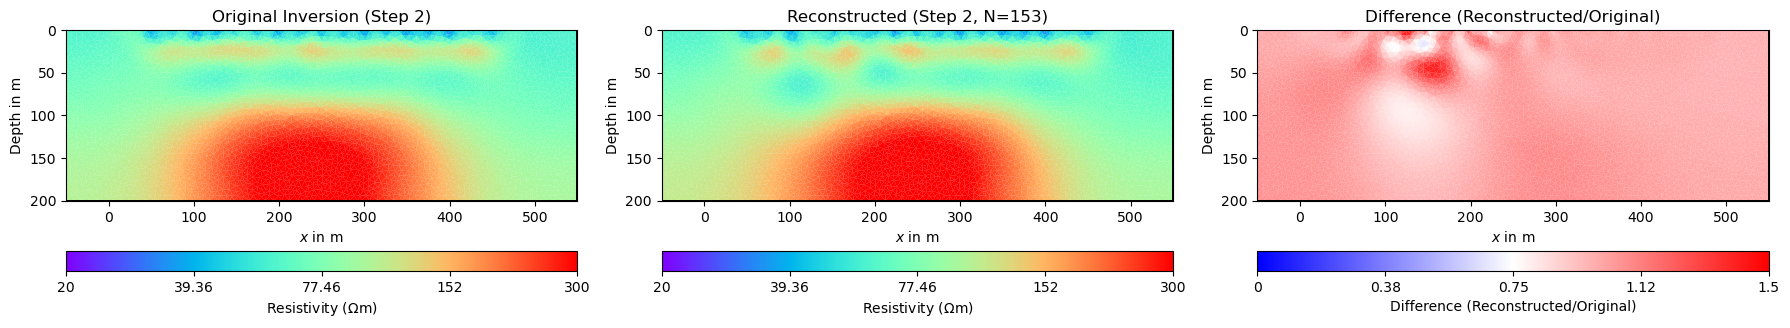

In [ ]:
comparisons_dir = os.path.join(output_dir, 'comparisons')
os.makedirs(comparisons_dir, exist_ok=True)
mesh = pg.load(f'{output_dir}/paraDomain_mesh.bms')
all_n_pixels = np.load(f'{output_dir}/all_n_pixels.npy').tolist()
all_inv1 = np.load(f'{output_dir}/inv1_list.npy', allow_pickle=True)
all_inv2 = np.load(f'{output_dir}/inv2_list.npy', allow_pickle=True)

steps_per_i = len(all_n_pixels) // 9

print("plotting...")

for target_step in range(9):
    for n_index in range(steps_per_i):
        idx = target_step * steps_per_i + n_index
        
        inv1 = all_inv1[idx]
        inv2 = all_inv2[idx]
        n_val = all_n_pixels[idx]
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        #original data inversion
        pg.show(mesh, inv1, ax=axes[0], cMap="rainbow", logScale=True, 
                cMin=20, cMax=300, colorBar=True, label="Resistivity ")
        axes[0].set_title(f"Original Inversion (Step {target_step})")
        
        #reconstructed data inversion
        pg.show(mesh, inv2, ax=axes[1], cMap="rainbow", logScale=True, 
                cMin=20, cMax=300, colorBar=True, label="Resistivity")
        axes[1].set_title(f"Reconstructed (Step {target_step}, N={n_val})")
        
        #ratio plots
        ratio = inv2 / inv1

            
        pg.show(mesh, ratio, ax=axes[2], cMap="bwr", logScale=False, 
                cMin=0, cMax=1.5, colorBar=True, label="Difference (Reconstructed/Original)")
        axes[2].set_title("Difference (Reconstructed/Original)")
        
        fig.tight_layout()
        plt.savefig(os.path.join(comparisons_dir, f'inv_comp_step_{target_step}_N_{n_val}.png'))
        plt.close(fig)
        print(f"Plotted Step {target_step} with N={n_val}")

print("done plotting")